In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from ps_script import lmbd, kp, write_bg, fname_bg, fname_ps, Np_autocalc, Np #load previously set parameters

ImportError: cannot import name 'lmbd' from 'ps_script' (/mnt/misc/SWIM_repo/PS_Calculator/Power_Spectrum/ps_script.py)

In [ ]:
#Power spectrum fitting function with running
def fitting_fn(lnk,lnAs,ns,alphs,betas):
    return lnAs + (lnk-np.log(kp))*(ns-1 + 0.5*alphs*(lnk-np.log(kp)) + (1/6)*betas*((lnk-np.log(kp))**2))

In [ ]:
#Load and plot Bg files
if (write_bg == True):
    Narr, phi_arr, php_arr, T_arr = np.loadtxt(fname_bg,unpack=True,delimiter=",",skiprows=1)

    plt.plot(Narr,phi_arr)
    plt.show()
    plt.plot(Narr,php_arr)
    plt.show()
    plt.plot(Narr,T_arr)
    plt.show()
else:
    print("BG file was not generated. Check the parameter 'write_bg' in ps_script.py")

In [ ]:
#Load and plot raw power spectrum files
karr,Parr = np.loadtxt(fname_ps,unpack=True,delimiter=",",skiprows=1)

plt.scatter(karr/kp,Parr)
plt.xscale("log")
plt.yscale("log")
plt.show()

In [27]:
#Smooth and fit the PS fitting function
Parr_sm = savgol_filter(Parr,15,3)
popt,pcov = curve_fit(fitting_fn,np.log(karr),np.log(Parr_sm))
print("As: ",np.exp(popt[0]))
print("ns: ",popt[1])
print("alpha_s: ",popt[2])
print("beta_s: ",popt[1])

As:  2.14368389488511e-09
ns:  0.9754863801319174
alpha_s:  -0.0007736525262794327
beta_s:  0.9754863801319174


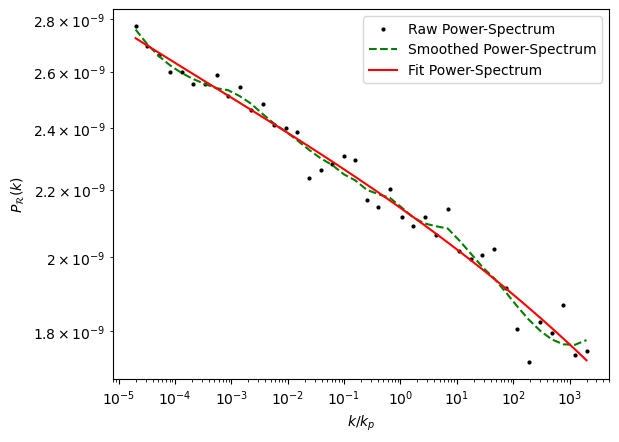

In [28]:
#Plot all the plots toget for comparison

plt.scatter(karr/kp,Parr,label="Raw Power-Spectrum",s=4,color='k')
plt.plot(karr/kp,Parr_sm,label="Smoothed Power-Spectrum",linestyle="--",color="green")
plt.plot(karr/kp,np.exp(fitting_fn(np.log(karr),popt[0],popt[1],popt[2],popt[3])),label="Fit Power-Spectrum",color="red")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.xlabel(r"$k/k_p$")
plt.ylabel(r"$P_\mathcal{R}(k)$")
plt.show()

N_end: 81.5824
N_reh: 88.0117
N_pivot:  21.594470597993563


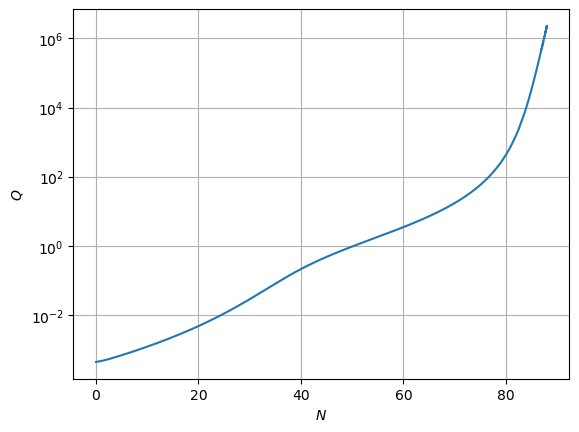

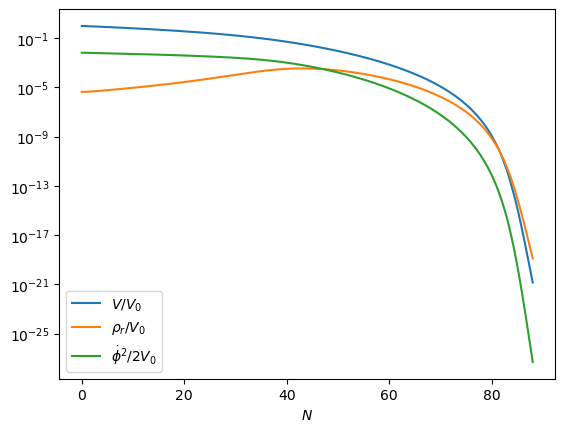

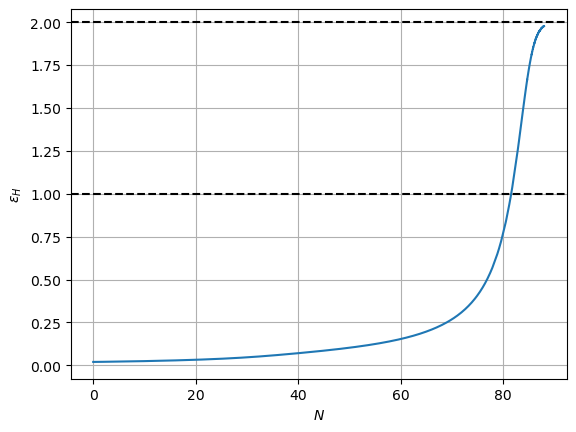

In [22]:
#Diagnostic plots for background
from scipy import optimize
from scipy.interpolate import CubicSpline
import functions_bg_diag as diag

Harr = diag.H(phi_arr, php_arr, T_arr)
Hparr = diag.Hp(phi_arr, php_arr, T_arr)
Qarr = diag.Q(phi_arr, php_arr, T_arr)
eHarr = diag.eH(phi_arr, php_arr, T_arr)

for i,j,k,l,m in zip(Narr,eHarr,T_arr,phi_arr,php_arr):
    if (j<=1.0):
        Nend = i
    elif ((j>1.0) and (j<=2.0)) or (weff(l,m,k)<0.33):
        Nreh = i
        Treh = k

#required to calculate Npivot
if (Np_autocalc == 1):
    Narr_uniq, indx = np.unique(Narr, return_index=True)
    phiasN = CubicSpline(Narr_uniq, phi_arr[indx])
    phpasN = CubicSpline(Narr_uniq, php_arr[indx])
    TasN = CubicSpline(Narr_uniq, T_arr[indx])
    def ff(Ntry):
        Htry = diag.H(phiasN(Ntry),phpasN(Ntry),TasN(Ntry))
        return (kp*2.63e-57) - (np.exp(Ntry-Nreh)*( (43.0/(11.0*(106.75)))**(1.0/3.0) )*((2.349e-13*4.11e-19)/(Treh))*(Htry));
    Npivot = optimize.bisect(ff,0,Nend,maxiter=20000)
else:
    Npivot = Np

print("N_end:",Nend)
print("N_reh:",Nreh)
print("N_pivot: ",Npivot)

#Q plot
plt.plot(Narr,Qarr)
plt.grid()
plt.yscale("log",base=10)
plt.ylabel("$Q$")
plt.xlabel("$N$")
plt.show()

#Energy densities plot
plt.plot(Narr,diag.V(phi_arr)/diag.V(phi_arr[0]),label=r"$V/V_0$")
plt.plot(Narr,(diag.Cr*T_arr**4)/diag.V(phi_arr[0]),label=r"$\rho_r/V_0$")
plt.plot(Narr,(((Harr*php_arr)**2)/2)/diag.V(phi_arr[0]),label=r"$\dot{\phi}^2/2V_0$")
plt.yscale("log",base=10)
plt.xlabel("$N$")
plt.legend()
plt.show()

#\epsilon_H plot
plt.plot(Narr,eHarr)
plt.axhline(1.0,linestyle="--",color="k")
plt.axhline(2.0,linestyle="--",color="k")
plt.xlabel("$N$")
plt.ylabel(r"$\epsilon_H$")
plt.grid()
plt.show()

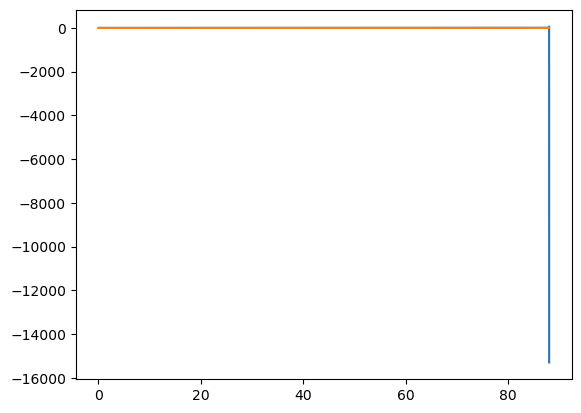

In [9]:
def H_N(N):
    phi = phiasN(N)
    php = phpasN(N)
    T = TasN(N)
    return diag.H(phi,php,T)
def Hp_N(N):
    phi = phiasN(N)
    php = phpasN(N)
    T = TasN(N)
    return diag.Hp(phi,php,T)
def num_derv (F, h,x):
    return ((-11.0*F(x))/6.0 + 3.0*F(h + x) - (3.0*F(2.0*h + x))/2.0 + F(3.0*h + x)/3.0)/h

plt.plot(Narr[10:-1],num_derv(Hp_N,1e-2,Narr[10:-1])/Harr[10:-1])
# plt.plot(Narr,np.gradient(Hparr,Narr)/Harr)
plt.plot(Narr,eHarr**2)
# plt.xlim(110)

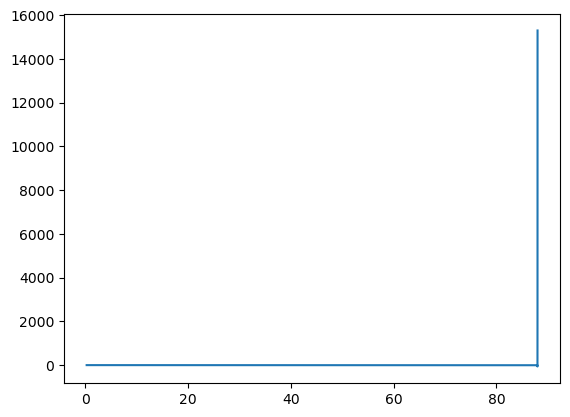

In [10]:
plt.plot(Narr[10:-1],(-num_derv(Hp_N,1e-2,Narr[10:-1])/Harr[10:-1])+eHarr[10:-1]**2)


In [11]:
(-num_derv(Hp_N,1e-2,Narr[10:-1])/Harr[10:-1])+eHarr[10:-1]**2

array([2.13435303e-04, 2.63886256e-04, 3.05625942e-04, ...,
       1.53043008e+04, 1.53043008e+04, 1.53043640e+04])

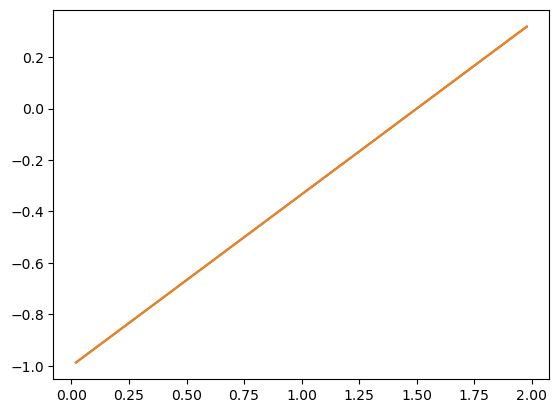

In [12]:
def weff(phi,php,T):
    Hi = diag.H(phi,php,T)
    rho_tot = diag.Cr*(T**4) + (((Hi*php)**2)/2) + diag.V(phi)
    p_tot = (1/3)*diag.Cr*(T**4)+ (((Hi*php)**2)/2) - diag.V(phi)
    return p_tot/rho_tot
plt.plot(eHarr,weff(phi_arr,php_arr,T_arr))
plt.plot(eHarr,(2/3)*eHarr-1)

In [13]:
print(weff(phi_arr,php_arr,T_arr))
print(eHarr)

[-0.986739   -0.986739   -0.986739   ...  0.31894185  0.31894173
  0.31894173]
[0.0198915  0.0198915  0.0198915  ... 1.97841278 1.9784126  1.9784126 ]


In [16]:
eHarr_uniq, indx = np.unique(eHarr, return_index=True)
warr = weff(phi_arr,php_arr,T_arr)
print(warr[-1])
cs = CubicSpline(eHarr_uniq,warr[indx])
cs(1.9999)

0.3189417343868377


array(-1029255.97199626)

In [91]:
warr_uniq = warr[indx]
print(warr_uniq)
print(eHarr_uniq)

[-0.99235555 -0.99235551 -0.99235547 ...  0.33333333  0.33333333
  0.33333333]
[0.01146667 0.01146673 0.0114668  ... 1.99999999 1.99999999 1.99999999]


In [107]:
(2/3)*1.97-1

0.31333333333333324